In [1]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import simulation_cpu  as sim
import scipy.special as scp
import analyze_tool as an




void siumllation verifction 
vector pointing anlize 

In [ ]:
time_cut = 100
lamda = 8e-7 
time_cycal= lamda/sim.c
pulse_width = 4*time_cycal 
fea = np.pi/2
dt = time_cycal/time_cut
dz = 2*sim.c *dt


eps_r = 1
sigma =0
    

pulse_width = 4*time_cycal
ms0 = [0, 0, 1]
alpha =0.0001

close_system = False

len_matiral = 2*lamda


z1 = int(2*pulse_width/dt) +3
z2 = z1 + int(len_matiral/dz) 
lenz= z2 + time_cut//2
pik_enter_step = 4*int(pulse_width/dt)


simulation_time = 2*pik_enter_step + 2*int(lenz) + 2*time_cut

save_location = np.arange(0,lenz-1,10)
save_location[:5] = np.arange(5)
save_time = []



check1
energy effact on pointing vec

Conclusion : We can see that vector pointing has all the energy we inject to the system.

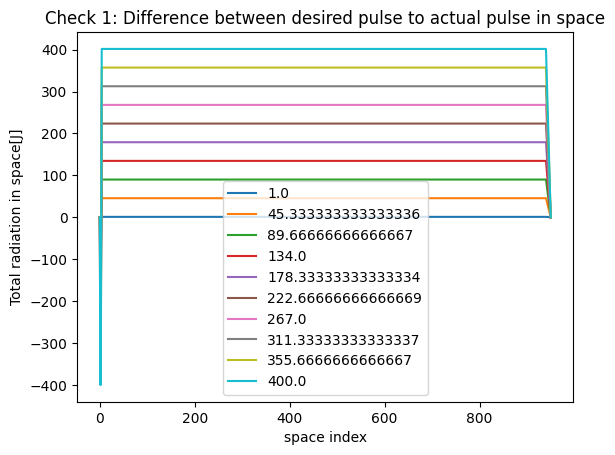

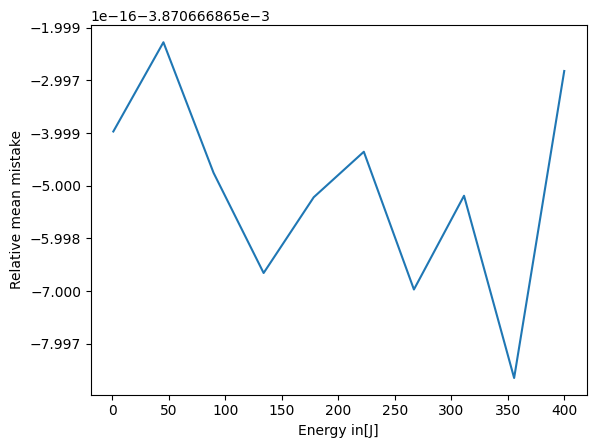

In [ ]:

energy_in = np.linspace(1, 400, 10)
S_comp = np.zeros(np.size(energy_in))

for i, E in enumerate(energy_in):
    
        
    time_res, spece_res = sim.simulation(z1, z2, eps_r , sigma, alpha, ms0,
            E, fea , pulse_width,
            save_location, save_time, False,
            dt, simulation_time, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))

    # for i, ind in enumerate(save_location):
    S_total_pass = np.sum(S,0)*dt
    S_comp[i] = np.mean(S_total_pass[5:-2,2])
    plt.plot(save_location, S_total_pass[:,2])
plt.legend(energy_in)
plt.xlabel("space index")
plt.title("Check 1: Difference between desired pulse power to actual pulse in space")
plt.ylabel("Total radiation in space[J]")
plt.show()
check1_s= (energy_in - S_comp)/energy_in
plt.plot(energy_in, check1_s)
plt.xlabel("Energy in[J]")
plt.ylabel("Relative mean mistake")
plt.show()

Check 2
pulse width efact on S

Conclusion - The mistake is getting smaller for wider pulses, and stabalizes for pulses wider 1.1 time cycles.

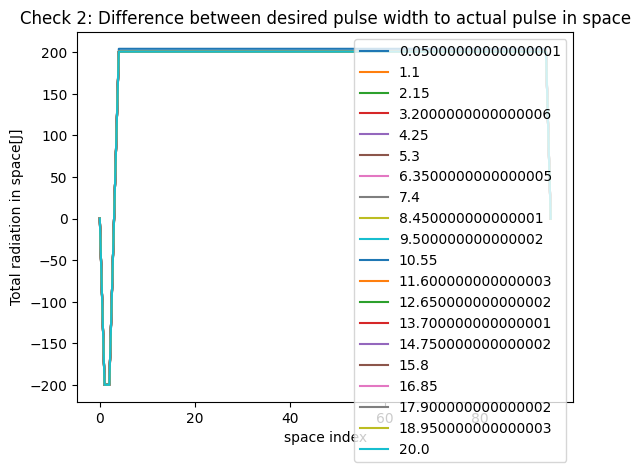

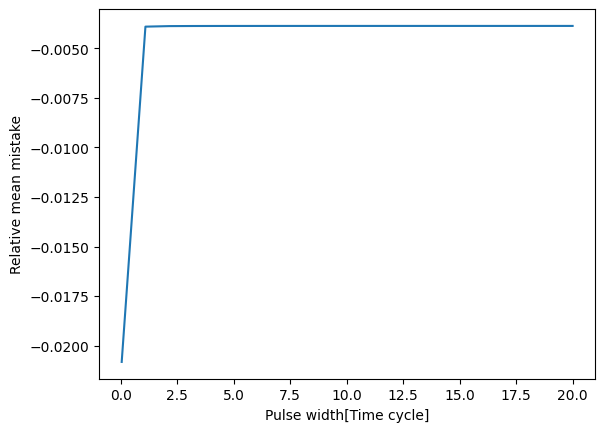

In [ ]:

pulse_width = np.linspace(0.05, 20 , 20) * time_cycal


pik_enter_step = 4*(pulse_width/dt)
time_run = 2* pik_enter_step + 2*int(lenz) + 2*time_cut
time_run = time_run.astype(int)

S_comp = np.zeros(np.size(pulse_width))
Powerin  = 200


for i, width in enumerate(pulse_width):
    run_time_in = time_run[i]
        
    time_res, spece_res = sim.simulation(z1, z2, eps_r , sigma, alpha, ms0,
            Powerin, fea , width,
            save_location, save_time, False,
            dt, run_time_in, lamda )

    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))

    S_total_pass = np.sum(S,0)*dt
    S_comp[i] = np.mean(S_total_pass[5:-2,2])
    plt.plot(S_total_pass[:,2])

plt.legend(pulse_width/time_cycal)
plt.xlabel("space index")
plt.title("Check 2: Difference between desired pulse width to actual pulse in space")
plt.ylabel("Total radiation in space[J]")
plt.show()
check2_s= (Powerin - S_comp)/Powerin
plt.plot(pulse_width/time_cycal , check2_s)
plt.xlabel("Pulse width[Time cycle]")
plt.ylabel("Relative mean mistake")
plt.show()







Check3 
time cut effect on S

Changing the time cuts!


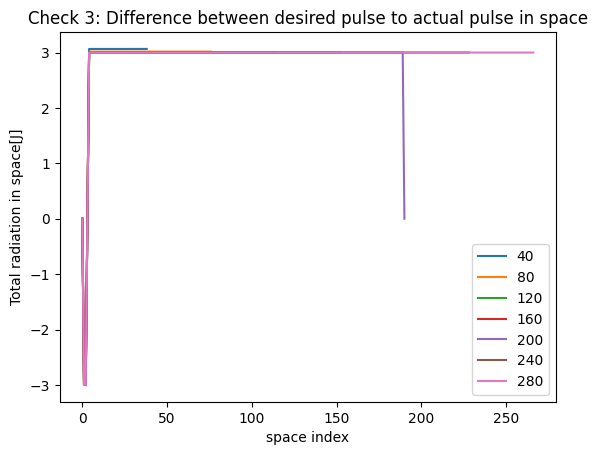

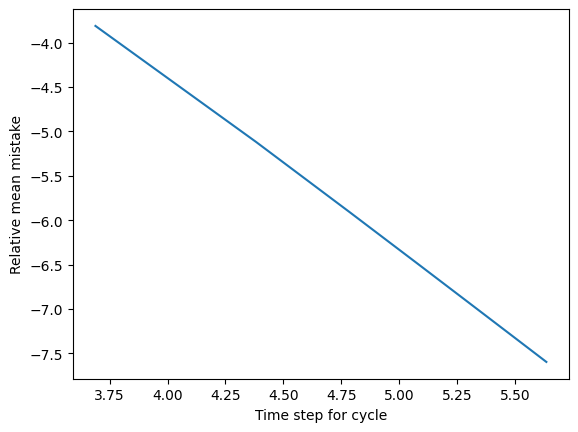

In [ ]:
times_cut = np.arange(40,300,40)
energy_in = 3
S_comp= np.zeros(np.size(times_cut))
pulse_width = 4*time_cycal


for i, t in enumerate(times_cut):
    dt_i = time_cycal/t
    pik_enter_step_i = 4*(pulse_width//dt_i)
    dz_i = 2*sim.c*dt_i
    
    z1_i = int(2*pulse_width/dt_i) +3
    z2_i = z1_i + int(len_matiral/dz_i) 
    lenz_i= z2_i + t//2
    time_run_i = int(2* pik_enter_step_i + 2*int(lenz_i) + 2*t)
    save_location_i = np.arange(0, lenz_i-1, 10)
    save_location_i[:5] = np.arange(5)
    time_res, spece_res = sim.simulation(z1_i, z2_i, eps_r , sigma, alpha, ms0,
            energy_in, fea , pulse_width,
            save_location_i, [], False,
            dt_i, time_run_i, lamda )
    
    E_real= sim.heta*spece_res[1]
    H = spece_res[0]
    S = np.cross(np.real(E_real),np.real(H))

    # for i, ind in enumerate(save_location):
    S_total_pass = np.sum(S,0)*dt_i
    S_comp[i] = np.mean(S_total_pass[5:-2,2])
    plt.plot(S_total_pass[:,2])

plt.legend(times_cut)
plt.xlabel("space index")
print("Changing the time cuts!")
plt.title("Check 3: Difference between desired pulse to actual pulse in space")
plt.ylabel("Total radiation in space[J]")
plt.show()
check3_s= abs((energy_in - S_comp)/energy_in)
plt.plot(np.log(times_cut), np.log(check3_s))
plt.xlabel("Time step for cycle")
plt.ylabel("Relative mean mistake")
plt.show()    

